# Keras + TensorFlow Models in Practice

This notebook contains full, runnable examples of:

- an MLP for tabular classification
- a CNN for image classification
- an LSTM for sequence regression
- a Transformer encoder for sequence regression

The goal is not only to define the models, but also to train them on synthetic data so the full pipeline becomes clear.

## Imports

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import TextVectorization
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Utility function for plotting training history

This helper function will let us visualize training and validation loss.

In [6]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="train_loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 3. Example 1 — MLP for tabular binary classification

We create synthetic tabular data:

- 1000 samples
- 20 features
- binary labels

Then we train a simple MLP.

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

x_tab = np.random.rand(1000, 20).astype(np.float32)
y_tab = (np.sum(x_tab, axis=1) > 10).astype(np.float32)

x_tab_train, x_tab_val = x_tab[:800], x_tab[800:]
y_tab_train, y_tab_val = y_tab[:800], y_tab[800:]

print("Train shape:", x_tab_train.shape)
print("Validation shape:", x_tab_val.shape)

Train shape: (800, 20)
Validation shape: (200, 20)


### Build the MLP

This is a standard feed-forward neural network:

- Dense(64)
- Dense(32)
- Dense(1, sigmoid)

Because the output is binary, we use:

- `sigmoid` activation
- `binary_crossentropy` loss

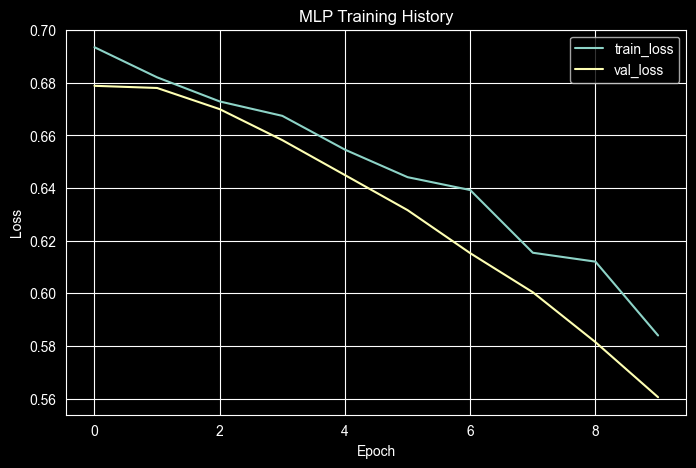

In [8]:
mlp_model = Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()

# Train the MLP
history_mlp = mlp_model.fit(
    x_tab_train, y_tab_train,
    validation_data=(x_tab_val, y_tab_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

# Plot the training history
plot_history(history_mlp, title="MLP Training History")

## 4. Example 2 — CNN for image classification

We create synthetic image data.

Each sample is:

- 32x32 RGB image
- one of 3 classes

This is fake data, but it is enough to demonstrate model structure and training mechanics.

In [9]:
x_img = np.random.rand(300, 32, 32, 3).astype(np.float32)
y_img = np.random.randint(0, 3, size=(300,))

x_img_train, x_img_val = x_img[:240], x_img[240:]
y_img_train, y_img_val = y_img[:240], y_img[240:]

print("Image train shape:", x_img_train.shape)
print("Image val shape:", x_img_val.shape)

Image train shape: (240, 32, 32, 3)
Image val shape: (60, 32, 32, 3)


### Build the CNN

This network uses:

- Conv2D for feature extraction
- MaxPooling2D for downsampling
- Flatten to convert feature maps to a vector
- Dense layers for classification

Because this is multiclass classification with integer labels, we use:

- `softmax` output
- `sparse_categorical_crossentropy` loss

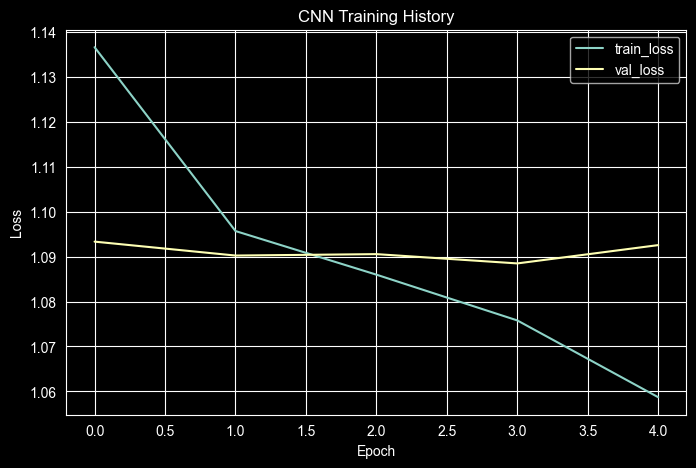

In [10]:
cnn_model = Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# Train the CNN
history_cnn = cnn_model.fit(
    x_img_train, y_img_train,
    validation_data=(x_img_val, y_img_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

# Plot the training history
plot_history(history_cnn, title="CNN Training History")

## 5. Example 3 — LSTM for sequence regression

We now work with sequential data.

Each sample contains:

- 40 time steps
- 8 features per time step

The target is a single continuous value, so this is a regression task.

In [11]:
x_seq = np.random.rand(500, 40, 8).astype(np.float32)
y_seq = np.sum(x_seq[:, -1, :], axis=1).astype(np.float32)

x_seq_train, x_seq_val = x_seq[:400], x_seq[400:]
y_seq_train, y_seq_val = y_seq[:400], y_seq[400:]

print("Sequence train shape:", x_seq_train.shape)
print("Sequence val shape:", x_seq_val.shape)

Sequence train shape: (400, 40, 8)
Sequence val shape: (100, 40, 8)


### Build the LSTM model

This model uses:

- LSTM to process the temporal structure
- Dense(1) for regression output

Because this is regression, we use:

- linear output
- mean squared error (`mse`)

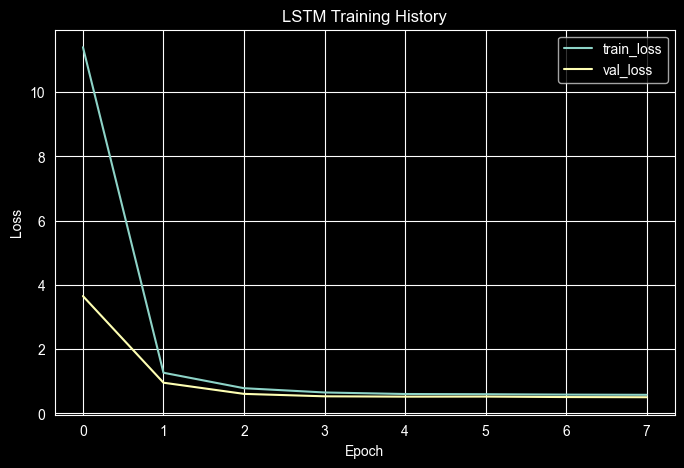

In [12]:
lstm_model = Sequential([
    layers.Input(shape=(40, 8)),
    layers.LSTM(64),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

# Train the LSTM
history_lstm = lstm_model.fit(
    x_seq_train, y_seq_train,
    validation_data=(x_seq_val, y_seq_val),
    epochs=8,
    batch_size=32,
    verbose=1
)


# Plot the training history
plot_history(history_lstm, title="LSTM Training History")

## 6. Example 4 — Transformer encoder for sequence regression

Now we build a small Transformer encoder model.

This is useful for sequence problems where each position should be able to attend to all others.

In [13]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim must be divisible by num_heads")

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads

        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]

        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)

        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        attention_output, _ = self.attention(query, key, value)

        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention_output, (batch_size, -1, self.embed_dim))

        return self.combine_heads(concat_attention)


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        return self.layernorm2(out1 + ffn_output)

In [14]:
x_trans = np.random.rand(500, 30, 12).astype(np.float32)
y_trans = np.mean(x_trans, axis=(1, 2)).astype(np.float32)

x_trans_train, x_trans_val = x_trans[:400], x_trans[400:]
y_trans_train, y_trans_val = y_trans[:400], y_trans[400:]

print("Transformer train shape:", x_trans_train.shape)
print("Transformer val shape:", x_trans_val.shape)



Transformer train shape: (400, 30, 12)
Transformer val shape: (100, 30, 12)


### Build the Transformer model

Steps:

1. project input features to embedding dimension
2. run a Transformer block
3. pool across sequence positions
4. predict a scalar

We use `GlobalAveragePooling1D` instead of `Flatten` because it is cleaner and usually more stable.

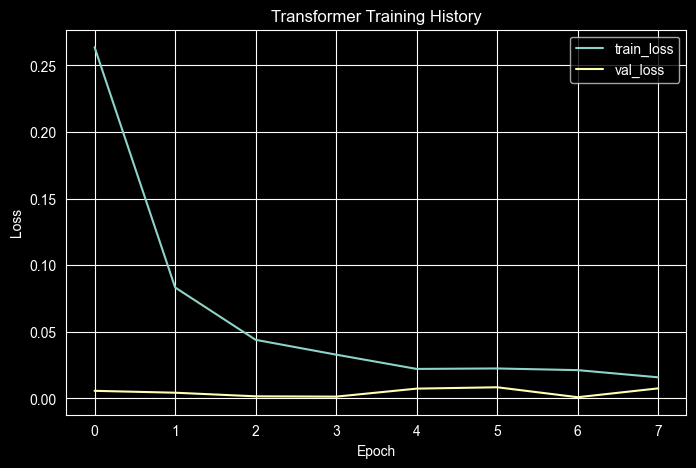

In [15]:
embed_dim = 64
num_heads = 4
ff_dim = 128

inputs = tf.keras.Input(shape=(30, 12))
x = layers.Dense(embed_dim)(inputs)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)

transformer_model = tf.keras.Model(inputs, outputs)

transformer_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

transformer_model.summary()

# Train the Transformer
history_transformer = transformer_model.fit(
    x_trans_train, y_trans_train,
    validation_data=(x_trans_val, y_trans_val),
    epochs=8,
    batch_size=32,
    verbose=1
)

# Plot the training history
plot_history(history_transformer, title="Transformer Training History")

## Implementing Transformers for Text Generation

In [17]:
# Load the dataset
from tensorflow.keras.utils import get_file
path_to_file = get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')

# Preview the dataset
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [19]:
# Preprocess the dataset
vocab_size = 10000
seq_length = 100

# Adapt TextVectorization to full text
vectorizer = TextVectorization(max_tokens=vocab_size, output_mode='int')
text_ds = tf.data.Dataset.from_tensor_slices([text]).batch(1)
vectorizer.adapt(text_ds)

# Vectorize the text
vectorized_text = vectorizer([text])[0]
print("Vectorized text shape:", vectorized_text.shape)
print("First 10 vectorized tokens:", vectorized_text.numpy()[:10])


Vectorized text shape: (202646,)
First 10 vectorized tokens: [ 89 270 138  36 982 144 673 125  16 106]


## Step 2: Create input and target sequences
Generate input and target sequences for training the Transformer model.

In the following code:

Define a function to generate input and target sequences.

Split the text data into sequences of the specified length.

Convert the sequences into TensorFlow tensors for training.

In [20]:
def create_sequences(text, seq_length):
    input_seqs = []
    target_seqs = []
    for i in range(len(text) - seq_length):
        input_seq = text[i:i + seq_length]
        target_seq = text[i + 1:i + seq_length + 1]
        input_seqs.append(input_seq)
        target_seqs.append(target_seq)
    return np.array(input_seqs), np.array(target_seqs)

# Generate sequences
X, Y = create_sequences(vectorized_text.numpy(), seq_length)

# Check if sequences are correctly generated
print("Number of sequences generated:", len(X))
print("Sample input sequence:", X[0] if len(X) > 0 else "No sequences generated")

# Check if X and Y are not empty
assert X.size > 0, "Input data X is empty"
assert Y.size > 0, "Target data Y is empty"
X = tf.convert_to_tensor(X)
Y = tf.convert_to_tensor(Y)
print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)


Number of sequences generated: 202546
Sample input sequence: [  89  270  138   36  982  144  673  125   16  106   34  106  106   89
  270    7   41   34 1286  344    4  200   64    4 3690   34 1286 1286
   89  270   89    7   93 1187  225   12 2442  592    4    2  307   34
   36 2655   36 2655   89  270   72   79  506   27    3   56   24 1390
   57   40  161 2328  644    9 4980   34   32   54 2863  885   72   17
   18  163  146  146  165  270   74  218   46  595   89  270   36   41
 6739  172  595    2 1780   46   29 1323 5151   47   58 4151   79   39
   60   58]
Shape of X: (202546, 100)
Shape of Y: (202546, 100)


## Step 3: Build the Transformer model


In [21]:
from tensorflow.keras.layers import Embedding, MultiHeadAttention, Dense, LayerNormalization, Dropout
from tensorflow.keras.models import Model

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TransformerModel(Model):  # Model is now properly imported
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, seq_length):
        super(TransformerModel, self).__init__()
        self.embedding = Embedding(vocab_size, embed_dim)
        self.pos_encoding = self.positional_encoding(seq_length, embed_dim)
        self.transformer_blocks = [TransformerBlock(embed_dim, num_heads, ff_dim) for _ in range(num_layers)]
        self.dense = Dense(vocab_size)

    def positional_encoding(self, seq_length, embed_dim):
        angle_rads = self.get_angles(np.arange(seq_length)[:, np.newaxis], np.arange(embed_dim)[np.newaxis, :], embed_dim)
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def get_angles(self, pos, i, embed_dim):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(embed_dim))
        return pos * angle_rates

    def call(self, inputs, training=False):
        seq_len = tf.shape(inputs)[1]
        x = self.embedding(inputs)
        x += self.pos_encoding[:, :seq_len, :]
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, training=training)  # Pass training argument correctly
        output = self.dense(x)
        return output

In [22]:
# Hyperparameters
embed_dim = 256
num_heads = 4
ff_dim = 512
num_layers = 4

# Build the Transformer model
model = TransformerModel(vocab_size, embed_dim, num_heads, ff_dim, num_layers, seq_length)

# Provide input shape to build the model by passing a dummy input with maxval specified
_ = model(tf.random.uniform((1, seq_length), maxval=vocab_size, dtype=tf.int32))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Summary of the model
model.summary()

 Non-trainable params: 0 (0.00 B)

## Step 4: Train the Transformer model


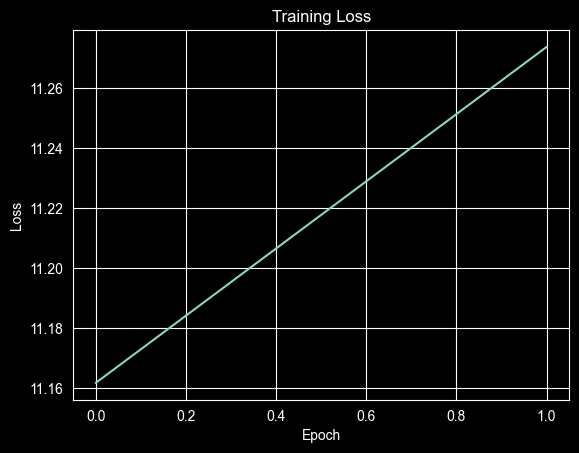

In [23]:
X = X[:10000]
Y = Y[:10000]

# Import necessary libraries for training visualization
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback to stop training if the loss doesn't improve
early_stopping = EarlyStopping(monitor='loss', patience=2, restore_best_weights=True)

# Train the transformer model on the full input and target sequences
history = model.fit(X, Y, epochs=2, batch_size=32, callbacks=[early_stopping])

# Plot training loss to monitor model performance over epochs
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


## Step 5: Generate text using the trained model

In [24]:
def generate_text(model, start_string, num_generate=100, temperature=1.0):
    # Convert the start string to a vectorized format
    input_eval = vectorizer([start_string]).numpy()

    # Ensure the input length is the same as the model's expected input shape
    if input_eval.shape[1] < seq_length:
        # Pad the input if it's shorter than the expected sequence length
        padding = np.zeros((1, seq_length - input_eval.shape[1]))
        input_eval = np.concatenate((padding, input_eval), axis=1)
    elif input_eval.shape[1] > seq_length:
        # Truncate the input if it's longer than the expected sequence length
        input_eval = input_eval[:, -seq_length:]

    input_eval = tf.convert_to_tensor(input_eval)

    # Initialize an empty list to store generated text
    text_generated = []

    # Start generating text
    for i in range(num_generate):
        # Make predictions using the model
        predictions = model(input_eval)

        # Remove only the batch dimension, keep the logits as 2D (batch_size, vocab_size)
        predictions = predictions[0]  # This should be of shape [vocab_size]

        # Apply temperature to predictions
        predictions = predictions / temperature

        # Use a categorical distribution to predict the next word
        predicted_id = tf.random.categorical(predictions, num_samples=1)[0, 0].numpy()

        # Update the input tensor to include the predicted word, maintaining the sequence length
        input_eval = np.append(input_eval.numpy(), [[predicted_id]], axis=1)  # Append predicted token
        input_eval = input_eval[:, -seq_length:]  # Keep only the last `seq_length` tokens
        input_eval = tf.convert_to_tensor(input_eval)  # Convert back to tensor

        # Append the predicted word to the generated text
        text_generated.append(vectorizer.get_vocabulary()[predicted_id])

    # Return the generated text starting from the initial seed
    return start_string + ' ' + ' '.join(text_generated)

# Generate text with temperature control
start_string = "To be, or not to be"
generated_text = generate_text(model, start_string, temperature=0.7)  # Lower temperature for more focused predictions
print(generated_text)

To be, or not to be evermore peppered populous wide scandalous throng speak welladvised your hum buried man wantst misdeed smoothd personally and disperse sugar blood smiling tongue ninescore fatherinlaw honesty vulgar highness she busy suburbs pouring blood provoke fails haggard citizen unpitied girls destroy shivering patchd presents vipers lineament my tragic take favour gust complices shouldbuzz province citizen lifeweary should gods jest here worldwearied frequent maimd gods restrained palpable lusts citizen railst twinkle traitor sacrificing recure an haggard shelves ramping win where yesterday stage gloves sheepwill forth gods selfplace scripture ripens heinous gods nothing take anguish done in bottle spoiled potion go swearst breed rites


## Adding learning rate scheduling to the training process

In [ ]:
# Define a learning rate scheduler
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch != 0:
        lr = lr * 0.5
    return lr


callback = tf.keras.callbacks.LearningRateScheduler(scheduler)


# Train the model with the learning rate scheduler
history = model.fit(X, Y, epochs=2, batch_size=64, callbacks=[callback])


# Plot the training loss
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss with Learning Rate Scheduler')
plt.show()

 24/157 ━━━━━━━━━━━━━━━━━━━━ 3:38 2s/step - loss: 11.2174